# Recherche des meilleurs hyperparamètres BERTopic

Ce notebook compare plusieurs configurations BERTopic, les classe selon plusieurs métriques, puis vérifie la stabilité des meilleures configurations.

In [1]:
import gc
import time
import warnings
from itertools import combinations
from pathlib import Path #pour la gestion des chemins de fichiers
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import ParameterGrid
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.feature_extraction.text import CountVectorizer

from umap import UMAP
from hdbscan import HDBSCAN
from hdbscan.validity import validity_index

from bertopic import BERTopic
from bertopic.vectorizers import ClassTfidfTransformer
from sentence_transformers import SentenceTransformer #pour les embeddings de phrase

from gensim.corpora import Dictionary
from gensim.models import CoherenceModel


warnings.filterwarnings("ignore")


In [2]:
# Racine du projet ZOLA-DTM
PROJECT_ROOT = Path.cwd().parent

# Dossiers principaux
DATA_DIR = PROJECT_ROOT / "data"
DONNEES_ANNEX_DIR = DATA_DIR / "donnees_annex"
CACHE_DIR = DONNEES_ANNEX_DIR / "data_cache"

# Fichier des embeddings
CHEMIN_EMBEDDINGS = CACHE_DIR / "embeddings_sentence_camembert.npy"

print("Répertoire courant :", Path.cwd())
print("Racine projet       :", PROJECT_ROOT)
print("Dossier data        :", DATA_DIR)
print("Dossier cache       :", CACHE_DIR)
print("Embeddings          :", CHEMIN_EMBEDDINGS)

Répertoire courant : /Users/morganr/zola-dtm/02_notebook_analyse
Racine projet       : /Users/morganr/zola-dtm
Dossier data        : /Users/morganr/zola-dtm/data
Dossier cache       : /Users/morganr/zola-dtm/data/donnees_annex/data_cache
Embeddings          : /Users/morganr/zola-dtm/data/donnees_annex/data_cache/embeddings_sentence_camembert.npy


## 1. Chargement du corpus et chargement ou calcul des embeddings

In [3]:
chemin_csv = Path("../data/2_processed/02_corpus_zola_lematise_128.csv")

print("cwd =", Path.cwd())
print("chemin_csv =", chemin_csv)
print("resolve =", chemin_csv.resolve())
print("exists =", chemin_csv.exists())

cwd = /Users/morganr/zola-dtm/02_notebook_analyse
chemin_csv = ../data/2_processed/02_corpus_zola_lematise_128.csv
resolve = /Users/morganr/zola-dtm/data/2_processed/02_corpus_zola_lematise_128.csv
exists = True


In [4]:
COL_TEXTE = "phrases_lemm"
COL_ROMAN = "roman"

RANDOM_STATE = 42

# Calculer DBCV peut ralentir légèrement la grille.
CALCULER_DBCV = True

# Nombre maximal de documents utilisés pour la silhouette.
TAILLE_ECHANTILLON_SILHOUETTE = 4000


df=pd.read_csv(Path(chemin_csv, encoding="utf-8"))


CHEMIN_EMBEDDINGS = Path("../data/donnees_annex/data_cache/embeddings_sentence_camembert.npy")

if CHEMIN_EMBEDDINGS.exists():
    print("Chargement des embeddings sauvegardés...")
    embeddings = np.load(CHEMIN_EMBEDDINGS, allow_pickle=False)
else:
    embedding_model = SentenceTransformer("dangvantuan/sentence-camembert-base")

    print("Génération des embeddings sémantiques...")
    embeddings = embedding_model.encode(
        df["texte"].tolist(),
        batch_size=64,
        show_progress_bar=True
    )
    CHEMIN_EMBEDDINGS.parent.mkdir(parents=True, exist_ok=True)
    np.save(CHEMIN_EMBEDDINGS, embeddings)
    print(f"Embeddings sauvegardés dans : {CHEMIN_EMBEDDINGS}")

Chargement des embeddings sauvegardés...


In [5]:
# Vérification des colonnes
assert COL_TEXTE in df.columns, (
    f"La colonne '{COL_TEXTE}' n'existe pas dans df.")
assert COL_ROMAN in df.columns, (
    f"La colonne '{COL_ROMAN}' n'existe pas dans df.")

# Conversion des embeddings
embeddings_array_initial = np.asarray(embeddings)

assert len(df) == len(embeddings_array_initial), (
    "Le nombre de lignes de df ne correspond pas "
    "au nombre d'embeddings.")

# Masque des documents non vides
masque_documents = (df[COL_TEXTE].notna() & df[COL_TEXTE].astype(str).str.strip().ne(""))

# DataFrame utilisé par BERTopic
df_model = (df.loc[masque_documents].copy().reset_index(drop=True))

# Documents
documents = (df_model[COL_TEXTE].astype(str).tolist())

# Romans associés aux documents
romans = (df_model[COL_ROMAN].astype(str).tolist())

# Embeddings alignés
embeddings_array = embeddings_array_initial[masque_documents.to_numpy()]

# Tokenisation simple pour la cohérence C_v
texts_tokenises = [
    document.split()
    for document in documents
]

# Dictionnaire Gensim
dictionary = Dictionary(texts_tokenises)


print("Nombre de documents :", len(documents))
print("Nombre de romans :", df_model[COL_ROMAN].nunique())
print("Dimensions des embeddings :", embeddings_array.shape)
print("Taille du dictionnaire :", len(dictionary))

Nombre de documents : 61432
Nombre de romans : 31
Dimensions des embeddings : (61432, 768)
Taille du dictionnaire : 23302


## 2. Fonctions d'évaluation

Ces fonctions calculent la cohérence, la diversité lexicale, la silhouette, le DBCV et les statistiques de couverture des topics.

In [6]:
def extraire_mots_topics(
    topic_model,
    labels,
    top_n_words=10,
    dictionary=None
):
    """
    Extrait les mots des topics, en excluant le topic -1.

    Si un dictionnaire Gensim est fourni, seuls les mots présents
    dans ce dictionnaire sont conservés.
    """

    labels = np.asarray(labels)

    topic_ids = sorted(
        int(topic_id)
        for topic_id in np.unique(labels)
        if topic_id != -1
    )

    topics_words = []

    for topic_id in topic_ids:

        representation = topic_model.get_topic(topic_id)

        if not representation:
            continue

        words = [
            word
            for word, _ in representation[:top_n_words]
        ]

        if dictionary is not None:
            words = [
                word
                for word in words
                if word in dictionary.token2id
            ]

        # Éviter les topics insuffisamment représentés
        if len(words) >= 2:
            topics_words.append(words)

    return topics_words

def calculer_coherence_cv(
    topic_model,
    labels,
    texts_tokenises,
    dictionary,
    top_n_words=10
):
    """
    Calcule la cohérence C_v des topics BERTopic.
    """

    topics_words = extraire_mots_topics(
        topic_model=topic_model,
        labels=labels,
        top_n_words=top_n_words,
        dictionary=dictionary
    )

    if len(topics_words) < 2:
        return np.nan

    try:
        coherence_model = CoherenceModel(
            topics=topics_words,
            texts=texts_tokenises,
            dictionary=dictionary,
            coherence="c_v",
            topn=top_n_words,
            processes=1
        )

        return float(coherence_model.get_coherence())

    except Exception:
        return np.nan
    
def calculer_diversite_topics(
    topic_model,
    labels,
    top_n_words=10
):
    """
    Diversité lexicale :
    nombre de termes uniques / nombre total de termes.
    """

    topics_words = extraire_mots_topics(
        topic_model=topic_model,
        labels=labels,
        top_n_words=top_n_words,
        dictionary=None
    )

    tous_les_mots = [
        word
        for topic_words in topics_words
        for word in topic_words
    ]

    if not tous_les_mots:
        return np.nan

    return len(set(tous_les_mots)) / len(tous_les_mots)    
    
def evaluer_modele(
    topic_model,
    topics,
    texts_tokenises,
    dictionary,
    silhouette_sample_size=2000,
    calculer_dbcv=True
):
    """
    Évalue un modèle BERTopic sur les topics bruts produits
    par HDBSCAN, avant toute réduction des outliers.
    """

    labels = np.asarray(topics, dtype=int)

    # Coordonnées UMAP utilisées par HDBSCAN
    embeddings_umap = np.asarray(
        topic_model.umap_model.embedding_,
        dtype=np.float64
    )

    masque_valides = labels != -1

    labels_valides = labels[masque_valides]
    embeddings_valides = embeddings_umap[masque_valides]

    topic_ids = np.unique(labels_valides)
    nombre_topics = len(topic_ids)

    nombre_documents = len(labels)
    nombre_assignes = int(masque_valides.sum())

    taux_outliers = float(np.mean(labels == -1))
    couverture = 1 - taux_outliers

    # --------------------------------------------------------------
    # Tailles des topics
    # --------------------------------------------------------------

    if nombre_topics > 0:

        tailles_topics = (
            pd.Series(labels_valides).value_counts())

        taille_min = int(tailles_topics.min())
        taille_mediane = float(tailles_topics.median())
        taille_max = int(tailles_topics.max())

        largest_topic_share = (
            taille_max / nombre_assignes
            if nombre_assignes > 0
            else np.nan
        )

    else:

        taille_min = np.nan
        taille_mediane = np.nan
        taille_max = np.nan
        largest_topic_share = np.nan

    # --------------------------------------------------------------
    # Silhouette dans l'espace UMAP
    # --------------------------------------------------------------

    silhouette = np.nan

    condition_silhouette = (
        nombre_topics >= 2
        and nombre_assignes > nombre_topics
    )

    if condition_silhouette:

        try:

            if nombre_assignes > silhouette_sample_size:

                silhouette = silhouette_score(
                    embeddings_valides,
                    labels_valides,
                    metric="euclidean",
                    sample_size=silhouette_sample_size,
                    random_state=RANDOM_STATE
                )

            else:

                silhouette = silhouette_score(
                    embeddings_valides,
                    labels_valides,
                    metric="euclidean"
                )

        except Exception:
            silhouette = np.nan

    # --------------------------------------------------------------
    # DBCV
    # --------------------------------------------------------------

    dbcv = np.nan

    if calculer_dbcv and nombre_topics >= 2:

        try:
            dbcv = validity_index(
                embeddings_umap,
                labels,
                metric="euclidean"
            )

            dbcv = float(dbcv)

        except Exception:
            dbcv = np.nan

    # --------------------------------------------------------------
    # Cohérence et diversité
    # --------------------------------------------------------------

    coherence_cv = calculer_coherence_cv(
        topic_model=topic_model,
        labels=labels,
        texts_tokenises=texts_tokenises,
        dictionary=dictionary,
        top_n_words=10
    )

    topic_diversity = calculer_diversite_topics(
        topic_model=topic_model,
        labels=labels,
        top_n_words=10
    )

    return {
        "n_documents": nombre_documents,
        "n_assigned": nombre_assignes,
        "n_topics": nombre_topics,
        "outlier_rate": taux_outliers,
        "coverage": couverture,
        "silhouette_umap": silhouette,
        "dbcv": dbcv,
        "coherence_cv": coherence_cv,
        "topic_diversity": topic_diversity,
        "min_topic_size_observed": taille_min,
        "median_topic_size": taille_mediane,
        "max_topic_size_observed": taille_max,
        "largest_topic_share": largest_topic_share
        }

## 3. Définition et exécution de la grille de recherche

In [7]:
n_documents = len(documents)

proportions = [0.002, 0.003, 0.004, 0.005]

min_cluster_sizes = [
    round(n_documents * proportion)
    for proportion in proportions
]

print(min_cluster_sizes)
# Environ : [123, 184, 246, 307]

[123, 184, 246, 307]


In [8]:
param_grid = {
    "n_neighbors": [40, 50, 60],
    "n_components": [5, 10, 15, 20],
    "min_cluster_size": [184, 246, 307],
    "min_samples": [1, 2]
}
configurations = list(ParameterGrid(param_grid))

print("Nombre de configurations à tester :",len(configurations))

Nombre de configurations à tester : 72


In [9]:
resultats = []

for numero, params in enumerate(configurations, start=1):

    print(
        f"\n{'=' * 70}\n"
        f"Configuration {numero}/{len(configurations)}\n"
        f"{params}"
    )

    debut = time.perf_counter()

    topic_model_test = None

    try:

        # ----------------------------------------------------------
        # UMAP
        # ----------------------------------------------------------
        umap_model = UMAP(
            n_neighbors=params["n_neighbors"],
            n_components=params["n_components"],
            min_dist=0.0,
            metric="cosine",
            random_state=RANDOM_STATE,
            low_memory=True)
        # ----------------------------------------------------------
        # HDBSCAN
        # ----------------------------------------------------------
        hdbscan_model = HDBSCAN(
            min_cluster_size=params["min_cluster_size"],
            min_samples=params["min_samples"],
            metric="euclidean",
            cluster_selection_method="eom",
            prediction_data=False,
            core_dist_n_jobs=-1)
        # ----------------------------------------------------------
        # Représentation lexicale
        # ----------------------------------------------------------
        vectorizer_model = CountVectorizer(
            min_df=2,
            max_df=0.8,
            ngram_range=(1, 1))

        ctfidf_model = ClassTfidfTransformer(
            reduce_frequent_words=True,
            bm25_weighting=True)
        # ----------------------------------------------------------
        # BERTopic
        # ----------------------------------------------------------
        topic_model_test = BERTopic(
            language="french",
            hdbscan_model=hdbscan_model,
            umap_model=umap_model,
            vectorizer_model=vectorizer_model,
            ctfidf_model=ctfidf_model,
            calculate_probabilities=False,
            nr_topics=None,
            verbose=False)

        topics_test, _ = topic_model_test.fit_transform(
            documents,
            embeddings=embeddings_array)
        # ----------------------------------------------------------
        # Évaluation
        # ----------------------------------------------------------
        metriques = evaluer_modele(
            topic_model=topic_model_test,
            topics=topics_test,
            texts_tokenises=texts_tokenises,
            dictionary=dictionary,
            silhouette_sample_size=TAILLE_ECHANTILLON_SILHOUETTE,
            calculer_dbcv=CALCULER_DBCV
        )
        duree = time.perf_counter() - debut

        ligne = {
            **params,
            **metriques,
            "duration_seconds": duree,
            "status": "ok",
            "error": None
        }

        print(
            f"Topics       : {metriques['n_topics']}\n"
            f"Outliers     : {metriques['outlier_rate']:.1%}\n"
            f"Silhouette   : {metriques['silhouette_umap']:.3f}\n"
            f"DBCV         : {metriques['dbcv']:.3f}\n"
            f"C_v          : {metriques['coherence_cv']:.3f}\n"
            f"Diversité    : {metriques['topic_diversity']:.3f}\n"
            f"Temps        : {duree:.1f} secondes"
        )

    except Exception as erreur:

        duree = time.perf_counter() - debut

        ligne = {
            **params,
            "n_documents": len(documents),
            "n_assigned": np.nan,
            "n_topics": np.nan,
            "outlier_rate": np.nan,
            "coverage": np.nan,
            "silhouette_umap": np.nan,
            "dbcv": np.nan,
            "coherence_cv": np.nan,
            "topic_diversity": np.nan,
            "min_topic_size_observed": np.nan,
            "median_topic_size": np.nan,
            "max_topic_size_observed": np.nan,
            "largest_topic_share": np.nan,
            "duration_seconds": duree,
            "status": "error",
            "error": str(erreur)
        }

        print("ERREUR :", erreur)

    resultats.append(ligne)
    
    resultats_df = pd.DataFrame(resultats)
    
    # Sauvegarde après chaque configuration
    chemin_sortie = Path("..") /"data" /"3_optimisation" /"resultats_grille_bertopic.csv"
    chemin_sortie.parent.mkdir(parents=True, exist_ok=True)
    resultats_df.to_csv(chemin_sortie, index=False, encoding="utf-8")
    

    # Nettoyage mémoire
    if topic_model_test is not None:
        del topic_model_test

    gc.collect()


Configuration 1/72
{'min_cluster_size': 184, 'min_samples': 1, 'n_components': 5, 'n_neighbors': 40}


: 

## 4. Classement multicritère des configurations

Les configurations sont filtrées puis comparées à partir de la cohérence, de la silhouette, du DBCV, de la diversité, de la couverture et de l'équilibre entre les topics.

In [9]:
resultats_df = pd.read_csv(Path("..") / "data" / "3_optimisation" / "resultats_grille_bertopic.csv")

resultats_valides = (resultats_df[resultats_df["status"] == "ok"].copy())

colonnes_affichage = [
    "n_neighbors",
    "n_components",
    "min_cluster_size",
    "min_samples",
    "n_topics",
    "outlier_rate",
    "silhouette_umap",
    "dbcv",
    "coherence_cv",
    "topic_diversity",
    "min_topic_size_observed",
    "median_topic_size",
    "max_topic_size_observed",
    "largest_topic_share",
    "duration_seconds"
]

display(
    resultats_valides[colonnes_affichage]
    .sort_values(
        ["coherence_cv", "silhouette_umap"],
        ascending=False
    )
    .head(20)
    .style.format({
        "outlier_rate": "{:.1%}",
        "silhouette_umap": "{:.3f}",
        "dbcv": "{:.3f}",
        "coherence_cv": "{:.3f}",
        "topic_diversity": "{:.3f}",
        "largest_topic_share": "{:.1%}",
        "duration_seconds": "{:.1f}"
    })
)

,n_neighbors,n_components,min_cluster_size,min_samples,n_topics,outlier_rate,silhouette_umap,dbcv,coherence_cv,topic_diversity,min_topic_size_observed,median_topic_size,max_topic_size_observed,largest_topic_share,duration_seconds
40,50,10,246,2,13,75.6%,0.406,-0.036,0.621,0.969,301,735.000000,5182,34.5%,106.2
46,50,20,246,2,14,74.6%,0.390,-0.018,0.616,0.971,276,627.500000,5186,33.2%,112.9
65,60,10,307,2,14,77.1%,0.480,-0.041,0.615,0.936,354,628.500000,2931,20.8%,102.5
2,60,5,184,1,17,73.1%,0.401,-0.091,0.610,0.965,185,538.000000,5378,32.5%,190.0
16,50,10,184,2,14,75.9%,0.408,-0.037,0.609,0.971,188,678.500000,5182,34.9%,333.7
10,50,20,184,1,19,73.6%,0.376,-0.035,0.604,0.963,215,519.000000,5690,35.1%,402.2
28,50,10,246,1,13,72.8%,0.398,-0.050,0.603,0.977,340,801.000000,5695,34.0%,98.4
52,50,10,307,1,13,72.8%,0.398,-0.050,0.603,0.977,340,801.000000,5695,34.0%,104.4
4,50,10,184,1,14,73.1%,0.399,-0.051,0.603,0.979,234,755.000000,5695,34.4%,244.0
31,50,15,246,1,18,76.5%,0.382,-0.028,0.602,0.939,301,542.000000,2794,19.4%,118.8


In [10]:
candidats = (
    resultats_valides
    .dropna(
        subset=[
            "n_topics",
            "outlier_rate",
            "silhouette_umap",
            "coherence_cv",
            "topic_diversity",
            "largest_topic_share"
        ]
    )
    .copy()
)

candidats = candidats[
     #Écarter les solutions triviales
    (candidats["n_topics"] >= 10) 

    # Écarter les modèles classant presque tout en bruit
    & (candidats["outlier_rate"] <= 0.75)

    # Écarter les modèles dominés par un seul topic
    & (candidats["largest_topic_share"] <= 0.40)
].copy()

print("Nombre de configurations valides :",len(candidats))

Nombre de configurations valides : 22


In [11]:
# Plus la valeur est élevée, mieux c'est
candidats["coherence_rank"] = (candidats["coherence_cv"].rank(pct=True))


candidats["silhouette_rank"] = (candidats["silhouette_umap"].rank(pct=True))


candidats["diversity_rank"] = (candidats["topic_diversity"].rank(pct=True))


candidats["coverage_rank"] = (candidats["coverage"].rank(pct=True))


# Une faible domination par le plus gros topic est préférable
candidats["balance_rank"] = ((1 - candidats["largest_topic_share"]).rank(pct=True))


# DBCV facultatif
if (CALCULER_DBCV and candidats["dbcv"].notna().sum() > 1):

    candidats["dbcv_rank"] = (candidats["dbcv"].rank(pct=True).fillna(0.5))

else:

    # Valeur constante : aucun effet sur le classement
    candidats["dbcv_rank"] = 0.5


# Score multicritère
candidats["score_global"] = (
    0.30 * candidats["coherence_rank"]
    + 0.20 * candidats["silhouette_rank"]
    + 0.15 * candidats["dbcv_rank"]
    + 0.15 * candidats["diversity_rank"]
    + 0.10 * candidats["coverage_rank"]
    + 0.10 * candidats["balance_rank"]
)

candidats = (candidats.sort_values("score_global",ascending=False,))


display(
    candidats[
        [
            "n_neighbors",
            "n_components",
            "min_cluster_size",
            "min_samples",
            "n_topics",
            "outlier_rate",
            "silhouette_umap",
            "dbcv",
            "coherence_cv",
            "topic_diversity",
            "largest_topic_share",
            "score_global"
        ]
    ]
    .head(20)
    .style.format({
        "outlier_rate": "{:.1%}",
        "silhouette_umap": "{:.3f}",
        "dbcv": "{:.3f}",
        "coherence_cv": "{:.3f}",
        "topic_diversity": "{:.3f}",
        "largest_topic_share": "{:.1%}",
        "score_global": "{:.3f}"
    })
)

,n_neighbors,n_components,min_cluster_size,min_samples,n_topics,outlier_rate,silhouette_umap,dbcv,coherence_cv,topic_diversity,largest_topic_share,score_global
46,50,20,246,2,14,74.6%,0.390,-0.018,0.616,0.971,33.2%,0.643
28,50,10,246,1,13,72.8%,0.398,-0.050,0.603,0.977,34.0%,0.643
52,50,10,307,1,13,72.8%,0.398,-0.050,0.603,0.977,34.0%,0.643
2,60,5,184,1,17,73.1%,0.401,-0.091,0.610,0.965,32.5%,0.635
4,50,10,184,1,14,73.1%,0.399,-0.051,0.603,0.979,34.4%,0.620
59,60,20,307,1,14,73.9%,0.420,-0.009,0.548,0.964,20.8%,0.618
57,40,20,307,1,14,72.0%,0.380,-0.034,0.577,1.000,36.8%,0.574
41,60,10,246,2,13,73.0%,0.416,-0.072,0.551,0.977,31.2%,0.569
22,50,20,184,2,17,74.6%,0.389,-0.019,0.567,0.982,33.2%,0.557
34,50,20,246,1,17,71.4%,0.376,-0.035,0.580,0.976,32.4%,0.555


In [12]:
meilleur_par_nombre_topics = (
    candidats
    .sort_values("score_global", ascending=False)
    .groupby("n_topics", as_index=False)
    .first()
    .sort_values("n_topics")
)


colonnes_par_nombre = [
    "n_topics",
    "n_neighbors",
    "n_components",
    "min_cluster_size",
    "min_samples",
    "outlier_rate",
    "silhouette_umap",
    "dbcv",
    "coherence_cv",
    "topic_diversity",
    "largest_topic_share",
    "score_global"
]


display(
    meilleur_par_nombre_topics[
        colonnes_par_nombre
    ]
    .style.format({
        "outlier_rate": "{:.1%}",
        "silhouette_umap": "{:.3f}",
        "dbcv": "{:.3f}",
        "coherence_cv": "{:.3f}",
        "topic_diversity": "{:.3f}",
        "largest_topic_share": "{:.1%}",
        "score_global": "{:.3f}"
    })
)

,n_topics,n_neighbors,n_components,min_cluster_size,min_samples,outlier_rate,silhouette_umap,dbcv,coherence_cv,topic_diversity,largest_topic_share,score_global
0,11,50,20,307,2,74.5%,0.423,-0.033,0.499,1.000,33.1%,0.553
1,13,50,10,246,1,72.8%,0.398,-0.050,0.603,0.977,34.0%,0.643
2,14,50,20,246,2,74.6%,0.390,-0.018,0.616,0.971,33.2%,0.643
3,15,40,20,246,2,74.7%,0.397,-0.017,0.562,0.973,37.3%,0.507
4,16,40,20,246,1,71.7%,0.370,-0.039,0.559,0.981,36.3%,0.464
5,17,60,5,184,1,73.1%,0.401,-0.091,0.610,0.965,32.5%,0.635
6,19,50,20,184,1,73.6%,0.376,-0.035,0.604,0.963,35.1%,0.489


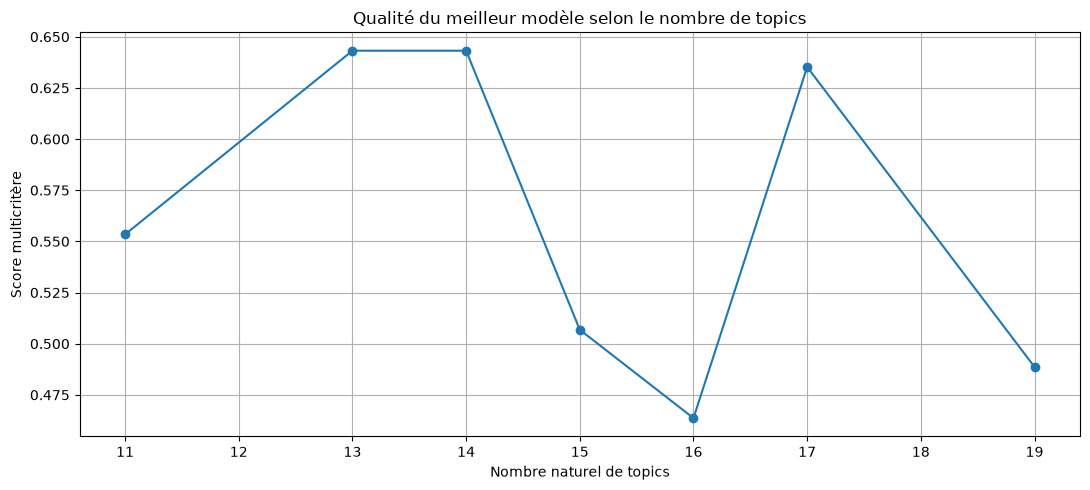

In [13]:
plt.figure(figsize=(11, 5))

plt.plot(
    meilleur_par_nombre_topics["n_topics"],
    meilleur_par_nombre_topics["score_global"],
    marker="o"
)
plt.xlabel("Nombre naturel de topics")
plt.ylabel("Score multicritère")
plt.title("Qualité du meilleur modèle selon le nombre de topics")

plt.grid(True)
plt.tight_layout()
plt.show()

## 5. Évaluation de la stabilité

Les meilleures configurations sont réentraînées avec plusieurs graines aléatoires afin de mesurer la stabilité des regroupements.

In [14]:
def entrainer_configuration(
    params,
    seed,
    documents,
    embeddings_array
):
    """
    Entraîne une configuration BERTopic avec une seed donnée.
    """

    umap_model = UMAP(
        n_neighbors=int(params["n_neighbors"]),
        n_components=int(params["n_components"]),
        min_dist=0.0,
        metric="cosine",
        random_state=int(seed),
        low_memory=True
    )

    hdbscan_model = HDBSCAN(
        min_cluster_size=int(params["min_cluster_size"]),
        min_samples=int(params["min_samples"]),
        metric="euclidean",
        cluster_selection_method="eom",
        prediction_data=False,
        core_dist_n_jobs=-1
    )

    vectorizer_model = CountVectorizer(
        min_df=2,
        max_df=0.8,
    )

    ctfidf_model = ClassTfidfTransformer(
        reduce_frequent_words=True,
        bm25_weighting=True
    )

    model = BERTopic(
        language="french",
        hdbscan_model=hdbscan_model,
        umap_model=umap_model,
        vectorizer_model=vectorizer_model,
        ctfidf_model=ctfidf_model,
        calculate_probabilities=False,
        nr_topics=None,
        verbose=False
    )

    topics, _ = model.fit_transform(documents, embeddings=embeddings_array)
    return model, np.asarray(topics)


def calculer_stabilite(listes_labels):
    """
    Compare plusieurs exécutions d'une même configuration.

    Deux mesures :
    - ARI sur tous les documents ;
    - ARI sur les documents assignés dans les deux exécutions.
    """

    ari_tous = []
    ari_assignes = []
    parts_communes = []

    for labels_a, labels_b in combinations(
        listes_labels,
        2
    ):

        labels_a = np.asarray(labels_a)
        labels_b = np.asarray(labels_b)

        # ARI comprenant le label -1
        ari_tous.append(
            adjusted_rand_score(
                labels_a,
                labels_b
            )
        )

        # Documents assignés dans les deux modèles
        masque_commun = (
            (labels_a != -1)
            & (labels_b != -1)
        )

        parts_communes.append(
            masque_commun.mean()
        )

        labels_a_communs = labels_a[masque_commun]
        labels_b_communs = labels_b[masque_commun]

        condition_ari = (
            len(labels_a_communs) >= 2
            and len(np.unique(labels_a_communs)) >= 2
            and len(np.unique(labels_b_communs)) >= 2
        )

        if condition_ari:

            ari_assignes.append(
                adjusted_rand_score(
                    labels_a_communs,
                    labels_b_communs
                )
            )

        else:

            ari_assignes.append(np.nan)

    return {
        "stability_ari_all_mean": np.nanmean(ari_tous),
        "stability_ari_all_std": np.nanstd(ari_tous),
        "stability_ari_assigned_mean": np.nanmean(
            ari_assignes
        ),
        "stability_ari_assigned_std": np.nanstd(
            ari_assignes
        ),
        "common_assigned_share": np.nanmean(
            parts_communes
        )
    }

In [33]:
N_MEILLEURS_MODELES = 10

SEEDS = [11, 30, 42, 57, 73]


top_configurations = (
    candidats
    .head(N_MEILLEURS_MODELES)
    .copy()
    .reset_index()
    .rename(columns={"index": "result_index"})
)


resultats_stabilite = []


for position, ligne in top_configurations.iterrows():

    params = {
        "n_neighbors": int(ligne["n_neighbors"]),
        "n_components": int(ligne["n_components"]),
        "min_cluster_size": int(
            ligne["min_cluster_size"]
        ),
        "min_samples": int(ligne["min_samples"])
    }

    print(
        f"\nConfiguration stable "
        f"{position + 1}/{len(top_configurations)}"
    )

    print(params)

    labels_par_seed = []
    nombres_topics = []
    taux_outliers = []

    for seed in SEEDS:

        print(f"  Seed {seed}")

        model_seed, labels_seed = (
            entrainer_configuration(
                params=params,
                seed=seed,
                documents=documents,
                embeddings_array=embeddings_array
            )
        )

        labels_par_seed.append(labels_seed)

        nombres_topics.append(
            len(
                np.unique(
                    labels_seed[labels_seed != -1]
                )
            )
        )

        taux_outliers.append(
            np.mean(labels_seed == -1)
        )

        del model_seed
        gc.collect()

    stabilite = calculer_stabilite(
        labels_par_seed
    )

    resultats_stabilite.append({
        "result_index": ligne["result_index"],
        **params,
        **stabilite,
        "mean_n_topics": np.mean(nombres_topics),
        "std_n_topics": np.std(nombres_topics),
        "mean_outlier_rate": np.mean(taux_outliers),
        "std_outlier_rate": np.std(taux_outliers)
    })


stabilite_df = pd.DataFrame(resultats_stabilite)

display(
    stabilite_df.style.format({
        "stability_ari_all_mean": "{:.3f}",
        "stability_ari_all_std": "{:.3f}",
        "stability_ari_assigned_mean": "{:.3f}",
        "stability_ari_assigned_std": "{:.3f}",
        "common_assigned_share": "{:.1%}",
        "mean_n_topics": "{:.1f}",
        "std_n_topics": "{:.2f}",
        "mean_outlier_rate": "{:.1%}",
        "std_outlier_rate": "{:.1%}"
    })
)




Configuration stable 1/5
{'n_neighbors': 60, 'n_components': 20, 'min_cluster_size': 120, 'min_samples': 1}
  Seed 11
  Seed 30
  Seed 42
  Seed 57
  Seed 73

Configuration stable 2/5
{'n_neighbors': 10, 'n_components': 10, 'min_cluster_size': 20, 'min_samples': 1}
  Seed 11
  Seed 30
  Seed 42
  Seed 57
  Seed 73

Configuration stable 3/5
{'n_neighbors': 10, 'n_components': 20, 'min_cluster_size': 20, 'min_samples': 1}
  Seed 11
  Seed 30
  Seed 42
  Seed 57
  Seed 73

Configuration stable 4/5
{'n_neighbors': 10, 'n_components': 15, 'min_cluster_size': 20, 'min_samples': 1}
  Seed 11
  Seed 30
  Seed 42
  Seed 57
  Seed 73

Configuration stable 5/5
{'n_neighbors': 10, 'n_components': 15, 'min_cluster_size': 120, 'min_samples': 1}
  Seed 11
  Seed 30
  Seed 42
  Seed 57
  Seed 73


,result_index,n_neighbors,n_components,min_cluster_size,min_samples,stability_ari_all_mean,stability_ari_all_std,stability_ari_assigned_mean,stability_ari_assigned_std,common_assigned_share,mean_n_topics,std_n_topics,mean_outlier_rate,std_outlier_rate
0,207,60,20,120,1,0.567,0.045,0.766,0.101,23.8%,17.2,0.75,68.1%,3.1%
1,4,10,10,20,1,0.183,0.155,0.495,0.290,33.0%,199.4,98.90,46.3%,22.9%
2,12,10,20,20,1,0.104,0.149,0.235,0.332,43.1%,148.0,119.31,35.2%,27.9%
3,8,10,15,20,1,0.186,0.162,0.406,0.334,32.4%,196.2,97.21,47.1%,22.9%
4,200,10,15,120,1,0.062,0.201,0.128,0.272,45.6%,10.4,10.37,37.6%,18.7%


# Si vous souhaitez reproduire les résultats, vous pouvez exécuter ce notebook dans l'ordre. Il est également possible de charger les résultats de la recherche d'hyperparamètres et de la stabilité depuis les fichiers CSV générés par ce notebook.

In [15]:
stabilite_df=pd.read_csv(Path("..") / "data" / "3_optimisation" / "stabilite_modeles_bertopic.csv")

display(
    stabilite_df.style.format({
        "stability_ari_all_mean": "{:.3f}",
        "stability_ari_all_std": "{:.3f}",
        "stability_ari_assigned_mean": "{:.3f}",
        "stability_ari_assigned_std": "{:.3f}",
        "common_assigned_share": "{:.1%}",
        "mean_n_topics": "{:.1f}",
        "std_n_topics": "{:.2f}",
        "mean_outlier_rate": "{:.1%}",
        "std_outlier_rate": "{:.1%}"
    })
)


,result_index,n_neighbors,n_components,min_cluster_size,min_samples,stability_ari_all_mean,stability_ari_all_std,stability_ari_assigned_mean,stability_ari_assigned_std,common_assigned_share,mean_n_topics,std_n_topics,mean_outlier_rate,std_outlier_rate
0,46,50,20,246,2,0.662,0.029,0.841,0.092,17.0%,15.6,1.20,77.8%,1.7%
1,28,50,10,246,1,0.640,0.026,0.852,0.086,18.2%,16.4,1.85,76.0%,2.4%
2,52,50,10,307,1,0.617,0.052,0.833,0.097,21.7%,12.8,1.83,71.7%,3.5%
3,4,50,10,184,1,0.649,0.025,0.851,0.089,17.8%,18.4,2.42,76.6%,2.1%
4,2,60,5,184,1,0.611,0.038,0.821,0.130,18.3%,19.6,1.74,75.3%,1.2%
5,59,60,20,307,1,0.620,0.051,0.733,0.090,22.1%,12.8,2.14,71.4%,2.5%
6,57,40,20,307,1,0.638,0.044,0.839,0.100,18.7%,14.2,0.75,75.3%,1.7%
7,34,50,20,246,1,0.652,0.028,0.861,0.085,18.8%,16.8,0.40,75.4%,2.2%
8,22,50,20,184,2,0.607,0.071,0.650,0.252,17.9%,16.2,2.79,75.9%,3.8%
9,41,60,10,246,2,0.655,0.039,0.800,0.086,18.0%,15.0,1.41,76.6%,2.9%


In [21]:
N_MEILLEURS_MODELES = 15

top_configurations=pd.read_csv(Path("..") / "data" / "3_optimisation" / "resultats_grille_bertopic.csv")
top_configurations= (
    candidats
    .head(N_MEILLEURS_MODELES)
    .copy()
    .reset_index()
    .rename(columns={"index": "result_index"})
)


In [22]:
top_configurations_stables = (
    top_configurations
    .merge(
        stabilite_df[
            [
                "result_index",
                "stability_ari_all_mean",
                "stability_ari_assigned_mean",
                "common_assigned_share",
                "mean_n_topics",
                "std_n_topics",
                "mean_outlier_rate"
            ]
        ],
        on="result_index",
        how="left"
    )
)


top_configurations_stables["stability_rank"] = (
    top_configurations_stables[
        "stability_ari_assigned_mean"
    ]
    .rank(pct=True)
    .fillna(0.5)
)


top_configurations_stables["score_final"] = (
    0.80
    * top_configurations_stables["score_global"]

    + 0.20
    * top_configurations_stables["stability_rank"]
)


top_configurations_stables = (top_configurations_stables.sort_values("score_final",ascending=False))


display(
    top_configurations_stables[
        [
            "n_neighbors",
            "n_components",
            "min_cluster_size",
            "min_samples",
            "n_topics",
            "outlier_rate",
            "coherence_cv",
            "silhouette_umap",
            "dbcv",
            "topic_diversity",
            "stability_ari_assigned_mean",
            "mean_n_topics",
            "std_n_topics",
            "score_global",
            "score_final"
        ]
    ]
    .style.format({
        "outlier_rate": "{:.1%}",
        "coherence_cv": "{:.3f}",
        "silhouette_umap": "{:.3f}",
        "dbcv": "{:.3f}",
        "topic_diversity": "{:.3f}",
        "stability_ari_assigned_mean": "{:.3f}",
        "mean_n_topics": "{:.1f}",
        "std_n_topics": "{:.2f}",
        "score_global": "{:.3f}",
        "score_final": "{:.3f}"
    })
)

,n_neighbors,n_components,min_cluster_size,min_samples,n_topics,outlier_rate,coherence_cv,silhouette_umap,dbcv,topic_diversity,stability_ari_assigned_mean,mean_n_topics,std_n_topics,score_global,score_final
1,50,10,246,1,13,72.8%,0.603,0.398,-0.050,0.977,0.852,16.4,1.85,0.643,0.699
0,50,20,246,2,14,74.6%,0.616,0.390,-0.018,0.971,0.841,15.6,1.20,0.643,0.668
4,50,10,184,1,14,73.1%,0.603,0.399,-0.051,0.979,0.851,18.4,2.42,0.620,0.666
9,50,20,246,1,17,71.4%,0.580,0.376,-0.035,0.976,0.861,16.8,0.40,0.555,0.644
2,50,10,307,1,13,72.8%,0.603,0.398,-0.050,0.977,0.833,12.8,1.83,0.643,0.638
3,60,5,184,1,17,73.1%,0.610,0.401,-0.091,0.965,0.821,19.6,1.74,0.635,0.616
6,40,20,307,1,14,72.0%,0.577,0.380,-0.034,1.000,0.839,14.2,0.75,0.574,0.598
5,60,20,307,1,14,73.9%,0.548,0.420,-0.009,0.964,0.733,12.8,2.14,0.618,0.541
10,50,20,307,2,11,74.5%,0.499,0.423,-0.033,1.000,0.803,11.8,0.75,0.553,0.520
11,60,10,307,1,13,69.6%,0.524,0.402,-0.093,0.977,nan,nan,nan,0.524,0.519


## 6. Choix du modèle retenu

Le modèle produisant 33 topics est retenu volontairement, car cette granularité paraît plus pertinente pour l'interprétation du corpus que la solution à 8 topics classée devant lui par le score automatique.

In [27]:
meilleure_ligne = top_configurations_stables.iloc[3]

# Même graine que pendant la grid search
SEED_FINALE = RANDOM_STATE  # 42

best_params = {
    "n_neighbors": int(meilleure_ligne["n_neighbors"]),
    "n_components": int(meilleure_ligne["n_components"]),
    "min_cluster_size": int(meilleure_ligne["min_cluster_size"]),
    "min_samples": int(meilleure_ligne["min_samples"]),
    "random_state": int(SEED_FINALE),
    "expected_n_topics": int(meilleure_ligne["n_topics"])
}

print("Meilleurs paramètres :")
print(best_params)

print(
    "\nGraine retenue :",
    best_params["random_state"]
)

print(
    "Nombre naturel de topics lors de la grille :",
    best_params["expected_n_topics"]
)

print(
    "Nombre moyen de topics sur plusieurs graines :",
    round(meilleure_ligne["mean_n_topics"], 1)
)

Meilleurs paramètres :
{'n_neighbors': 50, 'n_components': 20, 'min_cluster_size': 246, 'min_samples': 1, 'random_state': 42, 'expected_n_topics': 17}

Graine retenue : 42
Nombre naturel de topics lors de la grille : 17
Nombre moyen de topics sur plusieurs graines : 16.8


## 7. Export des résultats et des paramètres retenus

In [28]:
chemin_sortie = Path("..") /"data" /"3_optimisation" /"classement_modeles_bertopic.csv"
chemin_sortie.parent.mkdir(parents=True, exist_ok=True)
candidats.to_csv(chemin_sortie, index=False, encoding="utf-8")


chemin_sortie = Path("..") /"data" /"3_optimisation" /"stabilite_modeles_bertopic.csv"
chemin_sortie.parent.mkdir(parents=True, exist_ok=True)
stabilite_df.to_csv(chemin_sortie, index=False, encoding="utf-8")

dossier = Path("../data/donnees_annex")
dossier.mkdir(parents=True, exist_ok=True)
fichier = dossier / "meilleurs_parametres_bertopic.json"
with fichier.open("w", encoding="utf-8") as f:
    json.dump(best_params, f, indent=2, ensure_ascii=False)
    print(fichier.resolve())





/Users/morganr/zola-dtm/data/donnees_annex/meilleurs_parametres_bertopic.json
